# Reliability-Aware Early Radiographic Progression Modeling

This notebook implements:
- Baseline severe risk prediction
- Severity-stratified modeling
- Reliability and uncertainty analysis
- Distribution shift stress testing
- Temporal early progression modeling
- Latent state transition (digital twin prototype)


In [ ]:
# 1. Imports and Utility Functions
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import pydicom
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import pydicom
import cv2
import numpy as np
from torch.utils.data import DataLoader
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, brier_score_loss
import torch.nn.functional as F
from sklearn.metrics import average_precision_score
from sklearn.calibration import calibration_curve



In [2]:

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break


/kaggle/input


In [3]:


os.listdir('/kaggle/input/rsna-pneumonia-detection-challenge')


['stage_2_train_images',
 'stage_2_sample_submission.csv',
 'stage_2_detailed_class_info.csv',
 'GCP Credits Request Link - RSNA.txt',
 'stage_2_train_labels.csv',
 'stage_2_test_images']

# Dataset Preparation

In [4]:


labels = pd.read_csv('/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv')

labels.head()


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [5]:
print("Total rows in CSV:", len(labels))
print("Unique patients:", labels['patientId'].nunique())


Total rows in CSV: 30227
Unique patients: 26684


In [6]:
# Collapse to patient level
patient_labels = labels.groupby('patientId')['Target'].max().reset_index()

print("Total patients:", len(patient_labels))
print("Pneumonia patients:", patient_labels['Target'].sum())
print("No pneumonia patients:", len(patient_labels) - patient_labels['Target'].sum())
print("Pneumonia percentage:", patient_labels['Target'].mean() * 100)


Total patients: 26684
Pneumonia patients: 6012
No pneumonia patients: 20672
Pneumonia percentage: 22.530355269075102


In [7]:
# Compute area for each row
labels['area'] = labels['width'] * labels['height']

# Sum area per patient
severity = labels.groupby('patientId')['area'].sum().reset_index()
severity.columns = ['patientId', 'severity_score']

# Merge with patient-level labels
patient_data = patient_labels.merge(severity, on='patientId', how='left')

# Replace NaN (normal patients) with 0
patient_data['severity_score'] = patient_data['severity_score'].fillna(0)

# Look at pneumonia-only severity
pneumonia_only = patient_data[patient_data['Target'] == 1]

print(pneumonia_only['severity_score'].describe())


count      6012.000000
mean     123209.671657
std       99037.285561
min        3078.000000
25%       47433.000000
50%       91651.500000
75%      173322.750000
max      632892.000000
Name: severity_score, dtype: float64


In [8]:
# Define threshold
threshold = pneumonia_only['severity_score'].median()

# Create severe label (only meaningful for pneumonia patients)
patient_data['Severe'] = 0
patient_data.loc[patient_data['severity_score'] > threshold, 'Severe'] = 1

# Check distribution
print(patient_data['Severe'].value_counts())


Severe
0    23678
1     3006
Name: count, dtype: int64


In [9]:


# First split
train_data, temp_data = train_test_split(
    patient_data,
    test_size=0.30,
    stratify=patient_data['Severe'],
    random_state=42
)

# Second split
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data['Severe'],
    random_state=42
)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))


Train size: 18678
Validation size: 4003
Test size: 4003


In [10]:


base_path = "/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images"

train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

train_data['filepath'] = train_data['patientId'].apply(
    lambda x: os.path.join(base_path, x + ".dcm")
)

val_data['filepath'] = val_data['patientId'].apply(
    lambda x: os.path.join(base_path, x + ".dcm")
)

test_data['filepath'] = test_data['patientId'].apply(
    lambda x: os.path.join(base_path, x + ".dcm")
)

train_data[['patientId', 'filepath']].head()


,patientId,filepath
18650,ba1065ce-267d-422f-aef5-6d04c04402d8,/kaggle/input/rsna-pneumonia-detection-challen...
12740,868aa791-fca9-4915-b8e2-c38460d90426,/kaggle/input/rsna-pneumonia-detection-challen...
548,08090a05-52ae-42a2-91e4-35dd3a8641da,/kaggle/input/rsna-pneumonia-detection-challen...
1790,1831b4b0-803e-4950-9086-5455d74d6a44,/kaggle/input/rsna-pneumonia-detection-challen...
25011,f1a64f0e-6d10-4138-8d4f-af0573bd04e5,/kaggle/input/rsna-pneumonia-detection-challen...


In [11]:
train_data['filepath'].head(5)


18650    /kaggle/input/rsna-pneumonia-detection-challen...
12740    /kaggle/input/rsna-pneumonia-detection-challen...
548      /kaggle/input/rsna-pneumonia-detection-challen...
1790     /kaggle/input/rsna-pneumonia-detection-challen...
25011    /kaggle/input/rsna-pneumonia-detection-challen...
Name: filepath, dtype: object

In [12]:


sample_path = train_data['filepath'].iloc[0]
print(sample_path)
print("File exists:", os.path.exists(sample_path))


/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images/ba1065ce-267d-422f-aef5-6d04c04402d8.dcm
File exists: True


In [13]:
os.listdir("/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images")[:5]

['c3b05294-29be-46e4-8a51-96fd211e4ca5.dcm',
 '6a6ed2c5-d179-4c19-aac7-0d70eb87e024.dcm',
 '06550cfd-e9d5-415e-bae9-3146329ed9e6.dcm',
 'ef9eee29-6bdd-41da-ae40-9473592a9d5c.dcm',
 'c5dfc1a7-4669-42ce-af9f-62c3d8322049.dcm']

Image shape: (1024, 1024)
Pixel dtype: uint8


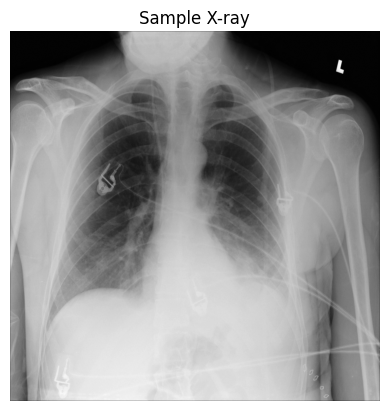

In [14]:

# Pick one sample image
sample_path = train_data['filepath'].iloc[0]

# Load DICOM
dicom = pydicom.dcmread(sample_path)

# Extract pixel array
image = dicom.pixel_array

print("Image shape:", image.shape)
print("Pixel dtype:", image.dtype)

# Show image
plt.imshow(image, cmap='gray')
plt.title("Sample X-ray")
plt.axis('off')
plt.show()


New shape: (224, 224, 3)
Min: 0.00035105797 Max: 0.9770642


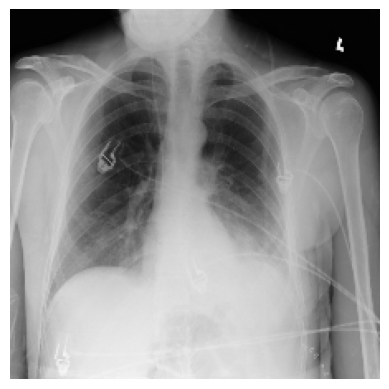

In [15]:

# Start with raw image
img = image.astype(np.float32)

# Normalize to 0–1
img = (img - img.min()) / (img.max() - img.min())

# Resize to 224x224
img_resized = cv2.resize(img, (224, 224))

# Convert to 3-channel (duplicate grayscale)
img_3ch = np.stack([img_resized]*3, axis=-1)

print("New shape:", img_3ch.shape)
print("Min:", img_3ch.min(), "Max:", img_3ch.max())

plt.imshow(img_3ch)
plt.axis('off')
plt.show()


In [16]:

class RSNADataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        
    def __len__(self):
        return len(self.df)
    
    def preprocess(self, img):
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())
        img = cv2.resize(img, (224, 224))
        img = np.stack([img]*3, axis=-1)
        img = np.transpose(img, (2, 0, 1))  # HWC → CHW
        return torch.tensor(img, dtype=torch.float32)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        dicom = pydicom.dcmread(row['filepath'])
        image = dicom.pixel_array
        
        image = self.preprocess(image)
        label = torch.tensor(row['Severe'], dtype=torch.float32)
        
        return image, label


In [17]:
train_dataset = RSNADataset(train_data)

sample_img, sample_label = train_dataset[0]

print("Tensor shape:", sample_img.shape)
print("Label:", sample_label)


Tensor shape: torch.Size([3, 224, 224])
Label: tensor(0.)


In [18]:

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataset = RSNADataset(val_data)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Test one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)


Batch image shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])


In [19]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla P100-PCIE-16GB


In [20]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

print("Model ready.")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 218MB/s]


Model ready.


In [22]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


In [23]:

model.train()

for images, labels in tqdm(train_loader):
    images = images.to(device)
    labels = labels.to(device).unsqueeze(1)
    
    optimizer.zero_grad()
    
    outputs = model(images)
    loss = criterion(outputs, labels)
    
    loss.backward()
    optimizer.step()

print("Finished 1 epoch")


100%|██████████| 1168/1168 [05:20<00:00,  3.64it/s]

Finished 1 epoch


In [24]:

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze()
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# AUROC
auc = roc_auc_score(all_labels, all_probs)

# Brier Score
brier = brier_score_loss(all_labels, all_probs)

print("Validation AUROC:", auc)
print("Validation Brier Score:", brier)


Validation AUROC: 0.8688943239248117
Validation Brier Score: 0.07726040648112838


In [25]:

auprc = average_precision_score(all_labels, all_probs)

print("Validation AUPRC:", auprc)


Validation AUPRC: 0.4489263038904011


In [26]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only last block (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

print("Model rebuilt with layer4 unfrozen.")


Model rebuilt with layer4 unfrozen.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [27]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    list(model.layer4.parameters()) + list(model.fc.parameters()),
    lr=1e-4
)


In [28]:

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")


100%|██████████| 1168/1168 [03:04<00:00,  6.34it/s]


Epoch 1, Loss: 0.2427886573004549


100%|██████████| 1168/1168 [02:52<00:00,  6.75it/s]


Epoch 2, Loss: 0.1758190965924208


100%|██████████| 1168/1168 [02:48<00:00,  6.93it/s]

Epoch 3, Loss: 0.09542200413902532


In [29]:

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze()
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy
import numpy as np
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# AUROC
auc = roc_auc_score(all_labels, all_probs)

# Brier Score
brier = brier_score_loss(all_labels, all_probs)

print("Validation AUROC:", auc)
print("Validation Brier Score:", brier)


Validation AUROC: 0.8874491869918698
Validation Brier Score: 0.0761282707820336


In [30]:

auprc = average_precision_score(all_labels, all_probs)

print("Validation AUPRC:", auprc)

Validation AUPRC: 0.5693723700068751


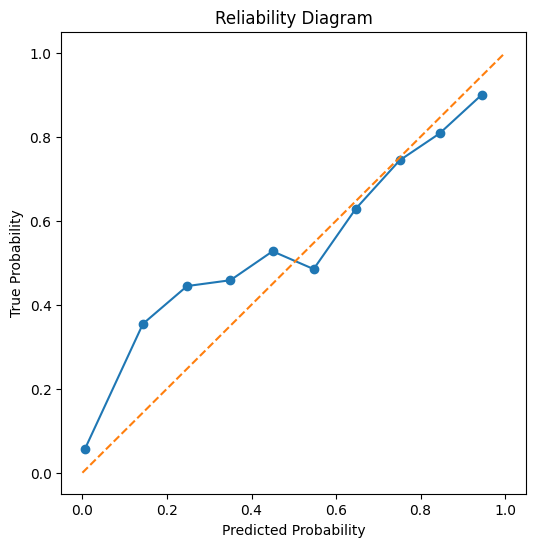

In [31]:

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    all_labels,
    all_probs,
    n_bins=10
)

# Plot
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Reliability Diagram")
plt.show()


In [32]:
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    ece = 0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(y_true)
    
    return ece

ece = compute_ece(all_labels, all_probs)
print("ECE:", ece)


ECE: 0.05867873854579671


# **Phase 2**

In [47]:
# Keep only pneumonia patients
pneumonia_data = patient_data[patient_data['Target'] == 1].copy()

print("Total pneumonia patients:", len(pneumonia_data))
print("Severe cases:", pneumonia_data['Severe'].sum())
print("Mild cases:", len(pneumonia_data) - pneumonia_data['Severe'].sum())


Total pneumonia patients: 6012
Severe cases: 3006
Mild cases: 3006


In [48]:
from sklearn.model_selection import train_test_split

train_pneu, temp_pneu = train_test_split(
    pneumonia_data,
    test_size=0.30,
    stratify=pneumonia_data['Severe'],
    random_state=42
)

val_pneu, test_pneu = train_test_split(
    temp_pneu,
    test_size=0.50,
    stratify=temp_pneu['Severe'],
    random_state=42
)

print("Train:", len(train_pneu))
print("Validation:", len(val_pneu))
print("Test:", len(test_pneu))


Train: 4208
Validation: 902
Test: 902


In [49]:
base_path = "/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images"

for df in [train_pneu, val_pneu, test_pneu]:
    df['filepath'] = df['patientId'].apply(
        lambda x: base_path + "/" + x + ".dcm"
    )

train_pneu[['patientId', 'Severe', 'filepath']].head()


,patientId,Severe,filepath
15301,9d315378-b59f-4999-a993-cc4443925be6,0,/kaggle/input/rsna-pneumonia-detection-challen...
4743,40f57a2e-1b3c-46fb-9350-558e34b8f4e9,0,/kaggle/input/rsna-pneumonia-detection-challen...
8759,641ead6c-0e54-4a5f-a3c3-e49d137ce16e,0,/kaggle/input/rsna-pneumonia-detection-challen...
23087,e16597e4-4bad-4d6b-819a-3f94dac2454d,0,/kaggle/input/rsna-pneumonia-detection-challen...
7786,5bc12970-af13-48bb-bd12-a5cc72fb7154,0,/kaggle/input/rsna-pneumonia-detection-challen...


In [50]:
from torch.utils.data import DataLoader

# Create datasets
train_dataset_p2 = RSNADataset(train_pneu)
val_dataset_p2 = RSNADataset(val_pneu)
test_dataset_p2 = RSNADataset(test_pneu)

# Create loaders
train_loader_p2 = DataLoader(train_dataset_p2, batch_size=16, shuffle=True)
val_loader_p2 = DataLoader(val_dataset_p2, batch_size=16, shuffle=False)


In [51]:
images, labels = next(iter(train_loader_p2))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Unique labels in batch:", labels.unique())


Batch image shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])
Unique labels in batch: tensor([0., 1.])


In [52]:
class ResNetWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(in_features, 1)
    
    def forward(self, x):
        features = self.backbone(x)
        features = self.dropout(features)
        return self.classifier(features)

model_p2 = ResNetWithDropout().to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [53]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    list(model_p2.backbone.layer4.parameters()) +
    list(model_p2.classifier.parameters()),
    lr=1e-4
)


In [54]:
from tqdm import tqdm

num_epochs = 3

for epoch in range(num_epochs):
    model_p2.train()
    running_loss = 0
    
    for images, labels in tqdm(train_loader_p2):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model_p2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader_p2)}")


100%|██████████| 263/263 [00:43<00:00,  6.00it/s]


Epoch 1, Loss: 0.6180548178379074


100%|██████████| 263/263 [00:36<00:00,  7.12it/s]


Epoch 2, Loss: 0.3988482762878839


100%|██████████| 263/263 [00:36<00:00,  7.25it/s]

Epoch 3, Loss: 0.16485263672816663


In [55]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import numpy as np

model_p2.eval()

all_probs_p2 = []
all_labels_p2 = []

with torch.no_grad():
    for images, labels in val_loader_p2:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_p2(images)
        probs = torch.sigmoid(outputs).squeeze()
        
        all_probs_p2.extend(probs.cpu().numpy())
        all_labels_p2.extend(labels.cpu().numpy())

all_probs_p2 = np.array(all_probs_p2)
all_labels_p2 = np.array(all_labels_p2)

auc_p2 = roc_auc_score(all_labels_p2, all_probs_p2)
auprc_p2 = average_precision_score(all_labels_p2, all_probs_p2)
brier_p2 = brier_score_loss(all_labels_p2, all_probs_p2)

print("Phase 2 Validation AUROC:", auc_p2)
print("Phase 2 Validation AUPRC:", auprc_p2)
print("Phase 2 Validation Brier:", brier_p2)


Phase 2 Validation AUROC: 0.7586835856264227
Phase 2 Validation AUPRC: 0.7458626767307485
Phase 2 Validation Brier: 0.23897234816673432


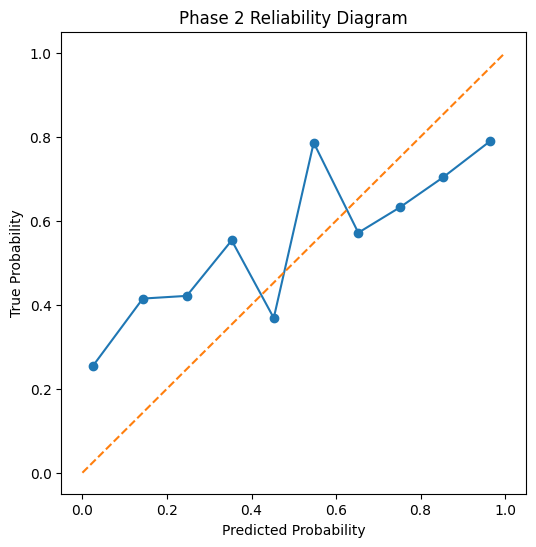

In [56]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

prob_true_p2, prob_pred_p2 = calibration_curve(
    all_labels_p2,
    all_probs_p2,
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_p2, prob_true_p2, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Phase 2 Reliability Diagram")
plt.show()


In [57]:
ece_p2 = compute_ece(all_labels_p2, all_probs_p2)
print("Phase 2 ECE:", ece_p2)


Phase 2 ECE: 0.19398130205544561


In [58]:
mean_probs_p2, var_probs_p2, mc_labels_p2 = mc_dropout_predict(
    model_p2,
    val_loader_p2,
    n_samples=20
)


In [61]:
print("Mean predictive variance (Phase 2):", var_probs_p2.mean())


Mean predictive variance (Phase 2): 0.0025384796


In [62]:
# Binary predictions
preds_p2 = (mean_probs_p2 >= 0.5).astype(int)

# Errors
errors_p2 = (preds_p2 != mc_labels_p2).astype(int)

print("Phase 2 error rate:", errors_p2.mean())

correct_uncertainty_p2 = var_probs_p2[errors_p2 == 0]
wrong_uncertainty_p2 = var_probs_p2[errors_p2 == 1]

print("Mean uncertainty (correct, P2):", correct_uncertainty_p2.mean())
print("Mean uncertainty (wrong, P2):", wrong_uncertainty_p2.mean())


Phase 2 error rate: 0.3148558758314856
Mean uncertainty (correct, P2): 0.0021595955
Mean uncertainty (wrong, P2): 0.0033629527


In [63]:
from sklearn.metrics import accuracy_score

sorted_idx_p2 = np.argsort(var_probs_p2)

coverages = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for c in coverages:
    n = int(len(sorted_idx_p2) * c)
    selected = sorted_idx_p2[:n]
    
    acc = accuracy_score(mc_labels_p2[selected], preds_p2[selected])
    print(f"Coverage {c:.1f}, Accuracy: {acc:.4f}")


Coverage 0.5, Accuracy: 0.7805
Coverage 0.6, Accuracy: 0.7394
Coverage 0.7, Accuracy: 0.7306
Coverage 0.8, Accuracy: 0.7060
Coverage 0.9, Accuracy: 0.7041
Coverage 1.0, Accuracy: 0.6851


# **Phase 3**

In [33]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ResNetWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        
        # Freeze early layers
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Unfreeze last block
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        
        in_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Identity()
        
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(in_features, 1)
    
    def forward(self, x):
        features = self.backbone(x)
        features = self.dropout(features)
        return self.classifier(features)

model = ResNetWithDropout().to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [34]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    list(model.backbone.layer4.parameters()) +
    list(model.classifier.parameters()),
    lr=1e-4
)


In [35]:


num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")


100%|██████████| 1168/1168 [03:00<00:00,  6.48it/s]


Epoch 1, Loss: 0.2394577305993601


100%|██████████| 1168/1168 [02:48<00:00,  6.94it/s]


Epoch 2, Loss: 0.17635273698347378


100%|██████████| 1168/1168 [02:50<00:00,  6.87it/s]

Epoch 3, Loss: 0.10073957517854742


In [36]:

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze()
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy
import numpy as np
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# AUROC
auc = roc_auc_score(all_labels, all_probs)

# Brier Score
brier = brier_score_loss(all_labels, all_probs)

print("Validation AUROC:", auc)
print("Validation Brier Score:", brier)


Validation AUROC: 0.8960555622140989
Validation Brier Score: 0.07835829309008414


In [37]:
from sklearn.metrics import average_precision_score

auprc = average_precision_score(all_labels, all_probs)

print("Validation AUPRC:", auprc)

Validation AUPRC: 0.5661968425266514


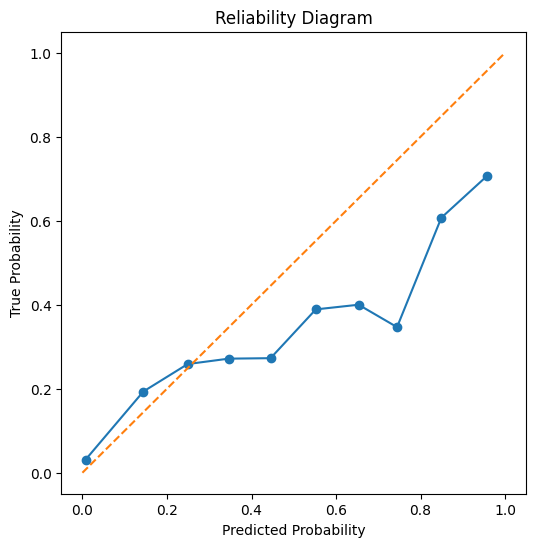

In [38]:

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    all_labels,
    all_probs,
    n_bins=10
)

# Plot
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Reliability Diagram")
plt.show()


In [39]:
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    ece = 0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(y_true)
    
    return ece

ece = compute_ece(all_labels, all_probs)
print("ECE:", ece)


ECE: 0.054323652292486146


In [40]:
def mc_dropout_predict(model, loader, n_samples=20):
    model.train()  # keep dropout active
    all_mean = []
    all_var = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            mc_outputs = []
            
            for _ in range(n_samples):
                outputs = model(images)
                probs = torch.sigmoid(outputs).squeeze()
                mc_outputs.append(probs.cpu().numpy())
            
            mc_outputs = np.stack(mc_outputs, axis=0)
            
            mean_probs = mc_outputs.mean(axis=0)
            var_probs = mc_outputs.var(axis=0)
            
            all_mean.extend(mean_probs)
            all_var.extend(var_probs)
            all_labels.extend(labels.numpy())
    
    return np.array(all_mean), np.array(all_var), np.array(all_labels)


In [41]:
mean_probs, var_probs, mc_labels = mc_dropout_predict(model, val_loader, n_samples=20)

print("Done MC Dropout.")


Done MC Dropout.


In [42]:
print(var_probs.mean())

0.0003794789


In [43]:
# Convert mean probabilities to binary predictions
preds = (mean_probs >= 0.5).astype(int)

# Compute errors (1 = wrong, 0 = correct)
errors = (preds != mc_labels).astype(int)

print("Overall error rate:", errors.mean())


Overall error rate: 0.10617037222083438


In [44]:
correct_uncertainty = var_probs[errors == 0]
wrong_uncertainty = var_probs[errors == 1]

print("Mean uncertainty (correct):", correct_uncertainty.mean())
print("Mean uncertainty (wrong):", wrong_uncertainty.mean())


Mean uncertainty (correct): 0.00024425055
Mean uncertainty (wrong): 0.0015179426


In [45]:
# Sort indices by uncertainty (ascending = most confident first)
sorted_idx = np.argsort(var_probs)

# Define coverage levels
coverages = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

from sklearn.metrics import roc_auc_score

for c in coverages:
    n = int(len(sorted_idx) * c)
    selected = sorted_idx[:n]
    
    auc = roc_auc_score(mc_labels[selected], mean_probs[selected])
    print(f"Coverage {c:.1f}, AUROC: {auc:.4f}")


Coverage 0.5, AUROC: 0.8060
Coverage 0.6, AUROC: 0.7950
Coverage 0.7, AUROC: 0.8303
Coverage 0.8, AUROC: 0.8908
Coverage 0.9, AUROC: 0.9044
Coverage 1.0, AUROC: 0.8921


In [46]:


for c in coverages:
    n = int(len(sorted_idx) * c)
    selected = sorted_idx[:n]
    
    acc = accuracy_score(mc_labels[selected], preds[selected])
    print(f"Coverage {c:.1f}, Accuracy: {acc:.4f}")


Coverage 0.5, Accuracy: 0.9880
Coverage 0.6, Accuracy: 0.9825
Coverage 0.7, Accuracy: 0.9772
Coverage 0.8, Accuracy: 0.9585
Coverage 0.9, Accuracy: 0.9314
Coverage 1.0, Accuracy: 0.8938


In [72]:
# Sort pneumonia patients by severity
pneumonia_sorted = pneumonia_data.sort_values(by='severity_score')

# Split severe and mild separately

severe_cases = pneumonia_data[pneumonia_data['Severe'] == 1].copy()
mild_cases = pneumonia_data[pneumonia_data['Severe'] == 0].copy()

# Sort severe cases by severity
severe_sorted = severe_cases.sort_values(by='severity_score')

# 80/20 split within severe
cutoff_severe = int(0.8 * len(severe_sorted))

train_severe = severe_sorted.iloc[:cutoff_severe]
test_severe = severe_sorted.iloc[cutoff_severe:]

# Random 80/20 split for mild cases
train_mild = mild_cases.sample(frac=0.8, random_state=42)
test_mild = mild_cases.drop(train_mild.index)

# Combine
train_shift = pd.concat([train_severe, train_mild]).copy()
test_shift = pd.concat([test_severe, test_mild]).copy()

print("Train shift label distribution:")
print(train_shift['Severe'].value_counts())

print("\nTest shift label distribution:")
print(test_shift['Severe'].value_counts())



Train shift label distribution:
Severe
0    2405
1    2404
Name: count, dtype: int64

Test shift label distribution:
Severe
1    602
0    601
Name: count, dtype: int64


In [74]:
base_path = "/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images"

for df in [train_shift, test_shift]:
    df['filepath'] = df['patientId'].apply(
        lambda x: base_path + "/" + x + ".dcm"
    )

#train_shift[['patientId','filepath']].head()

In [75]:


# Create datasets
train_dataset_shift = RSNADataset(train_shift)
test_dataset_shift = RSNADataset(test_shift)

# Create loaders
train_loader_shift = DataLoader(train_dataset_shift, batch_size=16, shuffle=True)
test_loader_shift = DataLoader(test_dataset_shift, batch_size=16, shuffle=False)

# Quick sanity check
images, labels = next(iter(train_loader_shift))
print("Batch shape:", images.shape)
print("Label distribution in batch:", labels.unique())


Batch shape: torch.Size([16, 3, 224, 224])
Label distribution in batch: tensor([0., 1.])


In [76]:
model_shift = ResNetWithDropout().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    list(model_shift.backbone.layer4.parameters()) +
    list(model_shift.classifier.parameters()),
    lr=1e-4
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [77]:
num_epochs = 3

for epoch in range(num_epochs):
    model_shift.train()
    running_loss = 0
    
    for images, labels in train_loader_shift:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model_shift(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader_shift)}")


Epoch 1, Loss: 0.6304397431520925
Epoch 2, Loss: 0.44394937083372643
Epoch 3, Loss: 0.20035025401913448


In [78]:
model_shift.eval()

all_probs_shift = []
all_labels_shift = []

with torch.no_grad():
    for images, labels in test_loader_shift:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_shift(images)
        probs = torch.sigmoid(outputs).squeeze()
        
        all_probs_shift.extend(probs.cpu().numpy())
        all_labels_shift.extend(labels.cpu().numpy())

all_probs_shift = np.array(all_probs_shift)
all_labels_shift = np.array(all_labels_shift)

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

auc_shift = roc_auc_score(all_labels_shift, all_probs_shift)
auprc_shift = average_precision_score(all_labels_shift, all_probs_shift)
brier_shift = brier_score_loss(all_labels_shift, all_probs_shift)

print("Shift Test AUROC:", auc_shift)
print("Shift Test AUPRC:", auprc_shift)
print("Shift Test Brier:", brier_shift)


Shift Test AUROC: 0.8852936136339765
Shift Test AUPRC: 0.8652847149401848
Shift Test Brier: 0.15934248803887166


In [79]:
mean_probs_shift, var_probs_shift, mc_labels_shift = mc_dropout_predict(
    model_shift,
    test_loader_shift,
    n_samples=20
)

print("Mean predictive variance (shift):", var_probs_shift.mean())


Mean predictive variance (shift): 0.0028259507


In [80]:
# Binary predictions
preds_shift = (mean_probs_shift >= 0.5).astype(int)

# Errors
errors_shift = (preds_shift != mc_labels_shift).astype(int)

print("Shift error rate:", errors_shift.mean())

correct_uncertainty_shift = var_probs_shift[errors_shift == 0]
wrong_uncertainty_shift = var_probs_shift[errors_shift == 1]

print("Mean uncertainty (correct, shift):", correct_uncertainty_shift.mean())
print("Mean uncertainty (wrong, shift):", wrong_uncertainty_shift.mean())


Shift error rate: 0.5012468827930174
Mean uncertainty (correct, shift): 0.002884032
Mean uncertainty (wrong, shift): 0.0027681582


# **Temporal**

In [82]:

labels_df = pd.read_csv(
    "/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"
)

print(labels_df.head())


                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1


In [84]:
image_counts = labels_df['patientId'].value_counts()

print("Max images per patient:", image_counts.max())
print("Patients with >1 image:", (image_counts > 1).sum())


Max images per patient: 4
Patients with >1 image: 3398


In [85]:

# Find a patient with multiple images
multi_patient = image_counts[image_counts > 1].index[0]

print("Example patient:", multi_patient)

# Get all rows for that patient
patient_rows = labels_df[labels_df['patientId'] == multi_patient]

# Load all images for that patient
base_path = "/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images"

for pid in patient_rows['patientId'].unique():
    filepath = os.path.join(base_path, pid + ".dcm")
    dicom = pydicom.dcmread(filepath)
    print("StudyDate:", getattr(dicom, "StudyDate", None))
    print("StudyTime:", getattr(dicom, "StudyTime", None))
    break


Example patient: ee820aa5-4804-4984-97b3-f0a71d69702f
StudyDate: 19010101
StudyTime: 000000.00


In [86]:
# Count images per patient
image_counts = labels_df['patientId'].value_counts()

# Patients with >=2 images
multi_patients = image_counts[image_counts >= 2].index

print("Total patients with >=2 images:", len(multi_patients))


Total patients with >=2 images: 3398


In [87]:
# Patient-level pneumonia labels (recreate safely)
patient_labels_df = labels_df.groupby('patientId')['Target'].max().reset_index()

# Pneumonia patients only
pneumonia_patients = patient_labels_df[patient_labels_df['Target'] == 1]['patientId']

# Intersect with multi-image patients
temporal_patients = set(pneumonia_patients).intersection(set(multi_patients))

print("Patients eligible for temporal modeling:", len(temporal_patients))


Patients eligible for temporal modeling: 3398


In [88]:
# Compute area per row
labels_df['area'] = labels_df['width'] * labels_df['height']

# Sum area per image (patientId corresponds to image file here)
image_severity = labels_df.groupby('patientId')['area'].sum().reset_index()

image_severity.columns = ['patientId', 'severity_score']

print("Total images with severity computed:", len(image_severity))
image_severity.head()


Total images with severity computed: 26684


,patientId,severity_score
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0.0
1,000924cf-0f8d-42bd-9158-1af53881a557,0.0
2,000db696-cf54-4385-b10b-6b16fbb3f985,139952.0
3,000fe35a-2649-43d4-b027-e67796d412e0,239669.0
4,001031d9-f904-4a23-b3e5-2c088acd19c6,480960.0


In [89]:
# Sort pneumonia images by severity
pneumonia_sorted = image_severity.merge(
    patient_labels_df,
    on='patientId'
)

# Keep pneumonia images only
pneumonia_sorted = pneumonia_sorted[pneumonia_sorted['Target'] == 1]

pneumonia_sorted = pneumonia_sorted.sort_values(by='severity_score')

n = len(pneumonia_sorted)

lower_cut = int(0.4 * n)
upper_cut = int(0.6 * n)

early_group = pneumonia_sorted.iloc[:lower_cut].copy()
future_group = pneumonia_sorted.iloc[upper_cut:].copy()

print("Early group size:", len(early_group))
print("Future group size:", len(future_group))


Early group size: 2404
Future group size: 2405


In [90]:
early_group['TemporalLabel'] = 0
future_group['TemporalLabel'] = 1

temporal_data = pd.concat([early_group, future_group]).copy()

print("Temporal dataset size:", len(temporal_data))
print("Label distribution:")
print(temporal_data['TemporalLabel'].value_counts())


Temporal dataset size: 4809
Label distribution:
TemporalLabel
1    2405
0    2404
Name: count, dtype: int64


In [91]:

train_temp, val_temp = train_test_split(
    temporal_data,
    test_size=0.2,
    stratify=temporal_data['TemporalLabel'],
    random_state=42
)

print("Train size:", len(train_temp))
print("Validation size:", len(val_temp))
print("Train label distribution:")
print(train_temp['TemporalLabel'].value_counts())


Train size: 3847
Validation size: 962
Train label distribution:
TemporalLabel
1    1924
0    1923
Name: count, dtype: int64


In [92]:
base_path = "/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images"

for df in [train_temp, val_temp]:
    df['filepath'] = df['patientId'].apply(
        lambda x: base_path + "/" + x + ".dcm"
    )

train_temp[['patientId', 'TemporalLabel', 'filepath']].head()


,patientId,TemporalLabel,filepath
12291,82099a84-dd20-48dd-a87a-7ffd3d948c8b,0,/kaggle/input/rsna-pneumonia-detection-challen...
133,0294b4aa-5614-4b33-80a4-2c31b639e5b3,0,/kaggle/input/rsna-pneumonia-detection-challen...
3160,339d0607-e869-4869-ac6d-379172682713,0,/kaggle/input/rsna-pneumonia-detection-challen...
19488,c21fd129-8438-42d2-9a6c-1284fecb4338,1,/kaggle/input/rsna-pneumonia-detection-challen...
1920,195ddf15-9620-4827-97da-01a44d5842f7,0,/kaggle/input/rsna-pneumonia-detection-challen...


In [93]:
class TemporalRSNADataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filepath = row['filepath']
        label = row['TemporalLabel']
        
        dicom = pydicom.dcmread(filepath)
        image = dicom.pixel_array.astype(np.float32)
        
        image = image / image.max()
        image = cv2.resize(image, (224, 224))
        image = np.stack([image]*3, axis=0)
        
        return torch.tensor(image, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


In [94]:
train_dataset_temp = TemporalRSNADataset(train_temp)
val_dataset_temp = TemporalRSNADataset(val_temp)

train_loader_temp = DataLoader(train_dataset_temp, batch_size=16, shuffle=True)
val_loader_temp = DataLoader(val_dataset_temp, batch_size=16, shuffle=False)

images, labels = next(iter(train_loader_temp))
print(images.shape)
print(labels.unique())


torch.Size([16, 3, 224, 224])
tensor([0., 1.])


In [95]:
model_temp = ResNetWithDropout().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    list(model_temp.backbone.layer4.parameters()) +
    list(model_temp.classifier.parameters()),
    lr=1e-4
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [96]:
num_epochs = 3

for epoch in range(num_epochs):
    model_temp.train()
    running_loss = 0
    
    for images, labels in train_loader_temp:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model_temp(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader_temp)}")


Epoch 1, Loss: 0.5396290674991133
Epoch 2, Loss: 0.3163538423687591
Epoch 3, Loss: 0.13799122023044533


In [97]:

model_temp.eval()

all_probs_temp = []
all_labels_temp = []

with torch.no_grad():
    for images, labels in val_loader_temp:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_temp(images)
        probs = torch.sigmoid(outputs).squeeze()
        
        all_probs_temp.extend(probs.cpu().numpy())
        all_labels_temp.extend(labels.cpu().numpy())

all_probs_temp = np.array(all_probs_temp)
all_labels_temp = np.array(all_labels_temp)

auc_temp = roc_auc_score(all_labels_temp, all_probs_temp)
auprc_temp = average_precision_score(all_labels_temp, all_probs_temp)
brier_temp = brier_score_loss(all_labels_temp, all_probs_temp)

print("Temporal Validation AUROC:", auc_temp)
print("Temporal Validation AUPRC:", auprc_temp)
print("Temporal Validation Brier:", brier_temp)


Temporal Validation AUROC: 0.8203024710301218
Temporal Validation AUPRC: 0.8153597988762528
Temporal Validation Brier: 0.19836420836010898


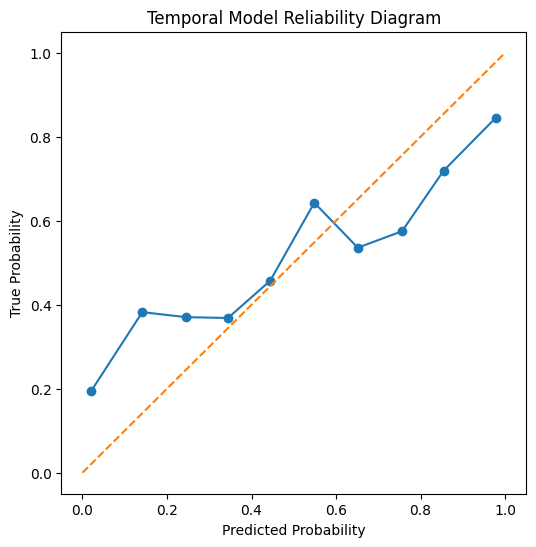

In [98]:

prob_true_temp, prob_pred_temp = calibration_curve(
    all_labels_temp,
    all_probs_temp,
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_temp, prob_true_temp, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Temporal Model Reliability Diagram")
plt.show()


In [99]:
ece_temp = compute_ece(all_labels_temp, all_probs_temp)
print("Temporal Model ECE:", ece_temp)


Temporal Model ECE: 0.1456508948748424


In [100]:
mean_probs_temp, var_probs_temp, mc_labels_temp = mc_dropout_predict(
    model_temp,
    val_loader_temp,
    n_samples=20
)

print("Temporal mean predictive variance:", var_probs_temp.mean())


Temporal mean predictive variance: 0.0018172666


In [101]:
# Binary predictions
preds_temp = (mean_probs_temp >= 0.5).astype(int)

# Errors
errors_temp = (preds_temp != mc_labels_temp).astype(int)

print("Temporal error rate:", errors_temp.mean())

correct_uncertainty_temp = var_probs_temp[errors_temp == 0]
wrong_uncertainty_temp = var_probs_temp[errors_temp == 1]

print("Mean uncertainty (correct, temporal):", correct_uncertainty_temp.mean())
print("Mean uncertainty (wrong, temporal):", wrong_uncertainty_temp.mean())


Temporal error rate: 0.2609147609147609
Mean uncertainty (correct, temporal): 0.0014150391
Mean uncertainty (wrong, temporal): 0.0029566449


In [102]:

sorted_idx_temp = np.argsort(var_probs_temp)

coverages = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for c in coverages:
    n = int(len(sorted_idx_temp) * c)
    selected = sorted_idx_temp[:n]
    
    acc = accuracy_score(mc_labels_temp[selected], preds_temp[selected])
    print(f"Coverage {c:.1f}, Accuracy: {acc:.4f}")


Coverage 0.5, Accuracy: 0.8482
Coverage 0.6, Accuracy: 0.8319
Coverage 0.7, Accuracy: 0.8083
Coverage 0.8, Accuracy: 0.7880
Coverage 0.9, Accuracy: 0.7618
Coverage 1.0, Accuracy: 0.7391


# **Digital twin**

In [103]:
def extract_embeddings(model, loader):
    model.eval()
    
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            
            features = model.backbone(images)  # state representation
            
            embeddings.append(features.cpu().numpy())
            labels.append(lbls.numpy())
    
    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)
    
    return embeddings, labels

emb_temp, labels_temp = extract_embeddings(model_temp, val_loader_temp)

print("Embedding shape:", emb_temp.shape)


Embedding shape: (962, 512)


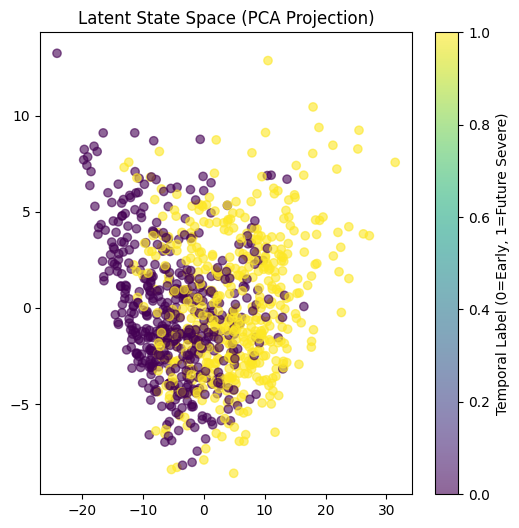

In [104]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_temp)

plt.figure(figsize=(6,6))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels_temp,
    alpha=0.6
)
plt.colorbar(label="Temporal Label (0=Early, 1=Future Severe)")
plt.title("Latent State Space (PCA Projection)")
plt.show()


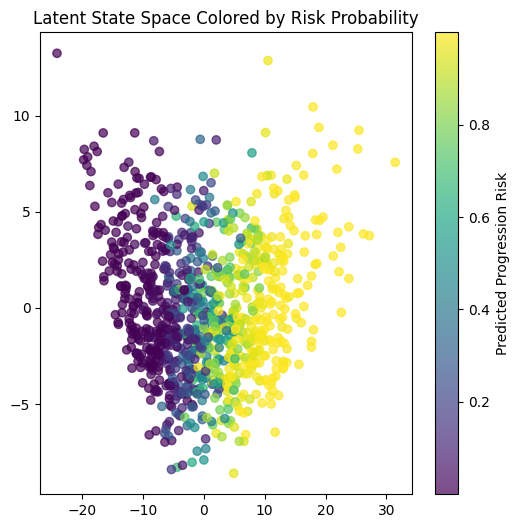

In [105]:
plt.figure(figsize=(6,6))
scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=all_probs_temp,
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, label="Predicted Progression Risk")
plt.title("Latent State Space Colored by Risk Probability")
plt.show()


In [106]:
# Separate embeddings by temporal label
early_emb = emb_temp[labels_temp == 0]
future_emb = emb_temp[labels_temp == 1]

# Compute mean state vectors
mu_early = early_emb.mean(axis=0)
mu_future = future_emb.mean(axis=0)

# Progression direction
d = mu_future - mu_early

# Normalize direction
d_norm = d / np.linalg.norm(d)

print("Direction vector norm:", np.linalg.norm(d_norm))


Direction vector norm: 0.99999994


In [107]:
# Project embeddings onto progression direction
progression_scores = emb_temp @ d_norm

print("Progression score range:")
print("Min:", progression_scores.min())
print("Max:", progression_scores.max())


Progression score range:
Min: -23.245699
Max: 31.351437


In [108]:
early_scores = progression_scores[labels_temp == 0]
future_scores = progression_scores[labels_temp == 1]

print("Mean progression score (early):", early_scores.mean())
print("Mean progression score (future):", future_scores.mean())


Mean progression score (early): -4.4560175
Mean progression score (future): 4.998662


In [109]:
from scipy.stats import pearsonr

corr, _ = pearsonr(progression_scores, all_probs_temp)

print("Correlation between twin coordinate and predicted risk:", corr)


Correlation between twin coordinate and predicted risk: 0.875897
